# 7.1 Cross-Source — Overview

**Input:** Newspapers, Polymarket, Polls, Financials, Google Trends  
**Output:** Correlation heatmap, key-events timeline

<!-- toc -->
## Contents
  - [Setup](#setup)
- [6. Correlation Overview](#6-correlation-overview)
    - [Key Takeaways Correlation Overview](#key-takeaways-correlation-overview)
- [7. Key-Events Timeline All Signals at a Glance](#7-key-events-timeline-all-signals-at-a-glance)
    - [Key Takeaways Key-Events Timeline (All Signals at a Glance)](#key-takeaways-key-events-timeline-all-signals-at-a-glance)


## Setup

In [29]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

import house_style as _hs
importlib.reload(_hs)  # force reload — voorkomt stale __pycache__ versie

from house_style import (
    apply_style,
    REPUBLICAN, DEMOCRAT, NEUTRAL, ACCENT,
    BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR,
    PALETTE,
    EVENTS,
    add_events, event_legend_handles,
    C_VIX, C_SP500,
    C_FEAR, C_ANGER, C_TRUST, C_DISGUST, C_SADNESS, C_JOY, C_ANTICIPATION,
    BLUESKY_BLUE, REDDIT_ORG,
)
apply_style()



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BRONZE = Path('../../Data/1_Bronze')
SILVER = Path('../../Data/2_Silver')

# ── Colour aliases ─────────────────────────────────────────────────────────
C_TRUMP  = REPUBLICAN
C_HARRIS = DEMOCRAT
C_DEM    = DEMOCRAT
C_REP    = REPUBLICAN
C_CEN    = NEUTRAL
C_MARKET = '#2ec4b6'
C_POLL   = '#9b5de5'

EVENT_DATES = [pd.Timestamp(date) for _, date, _ in EVENTS]

In [30]:
# ── Newspaper features ────────────────────────────────────────────────────────────
nlp  = pd.read_csv(SILVER / 'Newspapers/nlp_features_newspapers.csv',  parse_dates=['date'])
sent = pd.read_csv(SILVER / 'Newspapers/sentiment_features_newspapers.csv', parse_dates=['date'])

news = nlp.merge(sent, on='date', how='outer').sort_values('date').reset_index(drop=True)

# ── MediaCloud article-level → daily coverage metrics ────────────────────────
mc_raw = pd.read_csv(SILVER / 'Newspapers/mediacloud_articles_clean.csv', parse_dates=['date'])
mc_raw['mentions_trump']  = mc_raw['title_clean'].str.contains(r'\btrump\b',  case=False, na=False)
mc_raw['mentions_harris'] = mc_raw['title_clean'].str.contains(r'\bharris\b', case=False, na=False)

mc = (mc_raw.groupby('date')
     .agg(
         total_coverage   = ('title_clean', 'count'),
         n_trump_total    = ('mentions_trump',  'sum'),
         n_harris_total   = ('mentions_harris', 'sum'),
     )
     .reset_index())

denom = (mc['n_trump_total'] + mc['n_harris_total']).replace(0, float('nan'))
mc['trump_share']      = mc['n_trump_total'] / denom
mc['total_coverage_7d'] = mc['total_coverage'].rolling(7, min_periods=3).mean()
mc['trump_share_7d']    = mc['trump_share'].rolling(7,    min_periods=3).mean()

news = news.merge(mc, on='date', how='left')
print(f'Newspaper features : {news.shape}  ({news["date"].min().date()} → {news["date"].max().date()})')

Newspaper features : (118, 94)  (2024-07-05 → 2024-11-04)


In [31]:
# ── Polymarket odds ───────────────────────────────────────────────────────────────
poly = pd.read_csv(BRONZE / 'polymarket/polymarket_win_probabilities.csv',
                    parse_dates=['date'])
poly.columns = ['date', 'trump_odds', 'harris_odds']
poly = poly.sort_values('date').reset_index(drop=True)
print(f'Polymarket         : {poly.shape}  ({poly["date"].min().date()} → {poly["date"].max().date()})')
poly.head(3)

Polymarket         : (128, 3)  (2024-07-01 → 2024-11-05)


,date,trump_odds,harris_odds
0,2024-07-01,66.0,4.45
1,2024-07-02,65.0,9.65
2,2024-07-03,61.5,15.50


In [32]:
# ── Wikipedia polls → 7-day rolling average margin ─────────────────────────
polls_raw = pd.read_csv(BRONZE / 'polls/wikipedia_polls.csv')

# Parse numeric Trump/Harris support
for col in ['Trump', 'Harris']:
    polls_raw[col] = (
        polls_raw[col]
        .astype(str)
        .str.extract(r'([\d.]+)')[0]
        .astype(float)
    )

polls_raw['Date'] = pd.to_datetime(polls_raw['Date'], errors='coerce')
polls_raw = polls_raw.dropna(subset=['Date', 'Trump', 'Harris'])
polls_raw['margin'] = polls_raw['Trump'] - polls_raw['Harris']   # positive = Trump leads

# Daily average (multiple polls on same day)
daily_polls = (
    polls_raw.groupby('Date')[['Trump', 'Harris', 'margin']]
    .mean()
    .reset_index()
    .rename(columns={'Date': 'date', 'Trump': 'poll_trump', 'Harris': 'poll_harris'})
)

# Interpolate to full daily index, then smooth with 7-day rolling mean
date_idx = pd.date_range(daily_polls['date'].min(), daily_polls['date'].max(), freq='D')
daily_polls = (
    daily_polls.set_index('date')
    .reindex(date_idx)
    .interpolate('linear')
    .reset_index()
    .rename(columns={'index': 'date'})
)
daily_polls['poll_trump_7d']   = daily_polls['poll_trump'].rolling(7,  min_periods=1).mean()
daily_polls['poll_harris_7d']  = daily_polls['poll_harris'].rolling(7, min_periods=1).mean()
daily_polls['poll_margin_7d']  = daily_polls['margin'].rolling(7,      min_periods=1).mean()

print(f'Polls (daily interp): {daily_polls.shape}  ({daily_polls["date"].min().date()} → {daily_polls["date"].max().date()})')

Polls (daily interp): (134, 7)  (2024-06-24 → 2024-11-04)


In [33]:
# ── Financial market data ──────────────────────────────────────────────────────────
fin = pd.read_csv(BRONZE / 'financials/market.csv', parse_dates=['Date'])
fin = fin.rename(columns={'Date': 'date'})
fin = fin.sort_values('date').reset_index(drop=True)
print(f'Financials         : {fin.shape}  ({fin["date"].min().date()} → {fin["date"].max().date()})')

Financials         : (108, 6)  (2024-06-03 → 2024-11-04)


In [34]:
# ── Google Trends ──────────────────────────────────
gt = pd.read_csv(BRONZE / 'google_trends/trends_daily_stitched.csv', parse_dates=['date'])
gt = gt.sort_values('date').reset_index(drop=True)

gt = gt.rename(columns={
    'trump':         'gt_trump',
    'kamala':        'gt_kamala',
    'biden':         'gt_biden',
    'elon musk':     'gt_elon',
    'election 2024': 'gt_election',
    'vote':          'gt_vote',
    'conspiracy':    'gt_conspiracy',
    'walz':          'gt_walz',
    'vance':         'gt_vance',
    'campaign':      'gt_campaign',
})

gt['gt_trump_share']       = gt['gt_trump'] / (gt['gt_trump'] + gt['gt_kamala']).replace(0, np.nan)
gt['gt_election_interest'] = gt['gt_election']

print(f'Google Trends      : {gt.shape}  ({gt["date"].min().date()} → {gt["date"].max().date()})')
gt.head(3)


Google Trends      : (123, 8)  (2024-07-05 → 2024-11-04)


,date,gt_trump,gt_kamala,gt_vance,gt_walz,gt_election,gt_trump_share,gt_election_interest
0,2024-07-05,3.0,1.0,0.0,0.0,0.0,0.75,0.0
1,2024-07-06,3.0,0.0,0.0,0.0,0.0,1.00,0.0
2,2024-07-07,2.0,0.0,0.0,0.0,0.0,1.00,0.0


In [35]:
# ── Merge all sources on date ────────────────────────────────────────────────
df = (
    news
    .merge(poly,        on='date', how='left')
    .merge(daily_polls, on='date', how='left')
    .merge(fin,         on='date', how='left')
    .merge(gt,          on='date', how='left')
)
df = df.sort_values('date').reset_index(drop=True)

print(f'Master frame : {df.shape}')
print(f'Date range   : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Missing Polymarket   : {df["trump_odds"].isna().sum()} days')
print(f'Missing Financials   : {df["SP500"].isna().sum()} days (weekends/holidays)')
print(f'Missing Google Trends: {df["gt_trump"].isna().sum()} days')


Master frame : (118, 114)
Date range   : 2024-07-05 → 2024-11-04
Missing Polymarket   : 0 days
Missing Financials   : 37 days (weekends/holidays)
Missing Google Trends: 0 days


In [36]:
import matplotlib.lines as mlines

# ── Event helpers ──────────────────────────────────────────────────────────────
# EVENTS format: [(label, date_str, color), ...] imported from house_style
def add_events(ax, events=None, alpha=0.7):
    """Draw a coloured dashed vertical line for each event. No text on the plot."""
    if events is None:
        events = EVENTS
    for lbl, date_str, color in events:
        ax.axvline(pd.Timestamp(date_str), color=color,
                   linestyle='--', linewidth=1.3, alpha=alpha, zorder=3)

def event_legend(fig, ncol=3):
    """Place a coloured event legend centred at the bottom of fig."""
    handles = [
        mlines.Line2D([], [], color=c, linestyle='--', linewidth=2.5, label=lbl)
        for lbl, _, c in EVENTS
    ]
    fig.legend(
        handles=handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=ncol,
        facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
        fontsize=9, framealpha=0.95, borderpad=0.8,
    )

def fmt_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right')

def style_twin(ax2, ylabel=None, ylabel_color=TEXT_MUTED):
    """Apply dark-theme styling to a twinx axis."""
    ax2.set_facecolor(BG_PANEL)
    for sp in ax2.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
    ax2.tick_params(colors=TEXT_MUTED, labelsize=9)
    if ylabel:
        ax2.set_ylabel(ylabel, color=ylabel_color, fontsize=10)
    ax2.yaxis.label.set_color(ylabel_color)


# 6. Correlation Overview


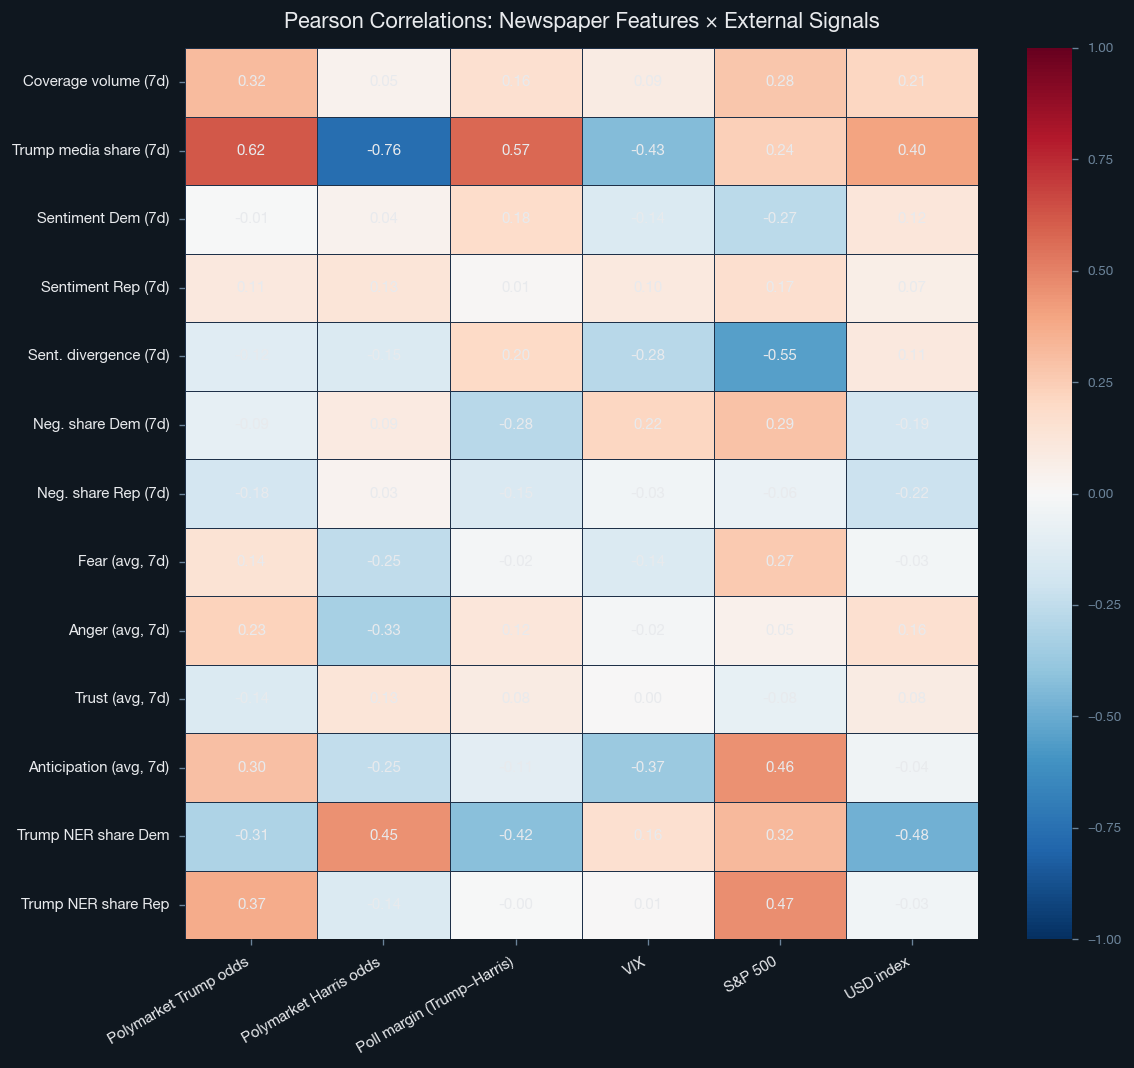


Strongest correlations with Polymarket Trump odds:
Trump media share (7d)    0.622
Trump NER share Rep       0.371
Coverage volume (7d)      0.317
Trump NER share Dem      -0.306
Anticipation (avg, 7d)    0.299
Anger (avg, 7d)           0.233
Neg. share Rep (7d)      -0.183
Fear (avg, 7d)            0.142
Trust (avg, 7d)          -0.142
Sent. divergence (7d)    -0.123
Sentiment Rep (7d)        0.108
Neg. share Dem (7d)      -0.090
Sentiment Dem (7d)       -0.005


In [38]:
# ── Derived columns needed for correlation ───────────────────────────────
df['sent_divergence'] = df['vader_compound_mean_dem'] - df['vader_compound_mean_rep']
df['sent_div_7d']     = df['sent_divergence'].rolling(7, min_periods=3).mean()
df['fear_avg']  = df[['nrc_fear_dem',  'nrc_fear_rep',  'nrc_fear_cen']].mean(axis=1)
df['anger_avg'] = df[['nrc_anger_dem', 'nrc_anger_rep', 'nrc_anger_cen']].mean(axis=1)
df['trust_avg'] = df[['nrc_trust_dem', 'nrc_trust_rep', 'nrc_trust_cen']].mean(axis=1)
df['antic_avg'] = df[['nrc_anticipation_dem', 'nrc_anticipation_rep', 'nrc_anticipation_cen']].mean(axis=1)

newspaper_features = {
    'Coverage volume (7d)':    'total_coverage_7d',
    'Trump media share (7d)':  'trump_share_7d',
    'Sentiment Dem (7d)':      'vader_compound_mean_dem',
    'Sentiment Rep (7d)':      'vader_compound_mean_rep',
    'Sent. divergence (7d)':   'sent_div_7d',
    'Neg. share Dem (7d)':     'vader_neg_share_dem',
    'Neg. share Rep (7d)':     'vader_neg_share_rep',
    'Fear (avg, 7d)':          'fear_avg',
    'Anger (avg, 7d)':         'anger_avg',
    'Trust (avg, 7d)':         'trust_avg',
    'Anticipation (avg, 7d)':  'antic_avg',
    'Trump NER share Dem':     'share_trump_dem',
    'Trump NER share Rep':     'share_trump_rep',
}

external_signals = {
    'Polymarket Trump odds':      'trump_odds',
    'Polymarket Harris odds':     'harris_odds',
    'Poll margin (Trump−Harris)': 'poll_margin_7d',
    'VIX':                        'VIX',
    'S&P 500':                    'SP500',
    'USD index':                  'USDIndex',
}

for label, col in list(newspaper_features.items()):
    if col in df.columns:
        df[col + '_r7'] = df[col].rolling(7, min_periods=3).mean()
        newspaper_features[label] = col + '_r7'

rows = list(newspaper_features.keys())
cols_ext = list(external_signals.keys())

sub = df[[c for c in newspaper_features.values() if c in df.columns] +
         [c for c in external_signals.values() if c in df.columns]].dropna()

corr_data = []
for row_label, row_col in newspaper_features.items():
    row_corrs = []
    for col_label, col_col in external_signals.items():
        if row_col in sub.columns and col_col in sub.columns:
            r = sub[row_col].corr(sub[col_col])
        else:
            r = np.nan
        row_corrs.append(r)
    corr_data.append(row_corrs)

corr_df = pd.DataFrame(corr_data, index=rows, columns=cols_ext)

fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

sns.heatmap(
    corr_df, annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', vmin=-1, vmax=1,
    linewidths=0.5, linecolor=SPINE_COLOR,
    ax=ax, annot_kws={'size': 9, 'color': TEXT_PRIMARY},
)

# Style colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors=TEXT_MUTED, labelsize=8)
cbar.outline.set_edgecolor(SPINE_COLOR)
cbar.ax.set_facecolor(BG_PANEL)

ax.set_title('Pearson Correlations: Newspaper Features × External Signals')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', color=TEXT_PRIMARY)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color=TEXT_PRIMARY)
plt.tight_layout()
plt.show()

print('\nStrongest correlations with Polymarket Trump odds:')
print(corr_df['Polymarket Trump odds'].sort_values(key=abs, ascending=False).round(3).to_string())


### Key Takeaways Correlation Overview


# 7. Key-Events Timeline All Signals at a Glance


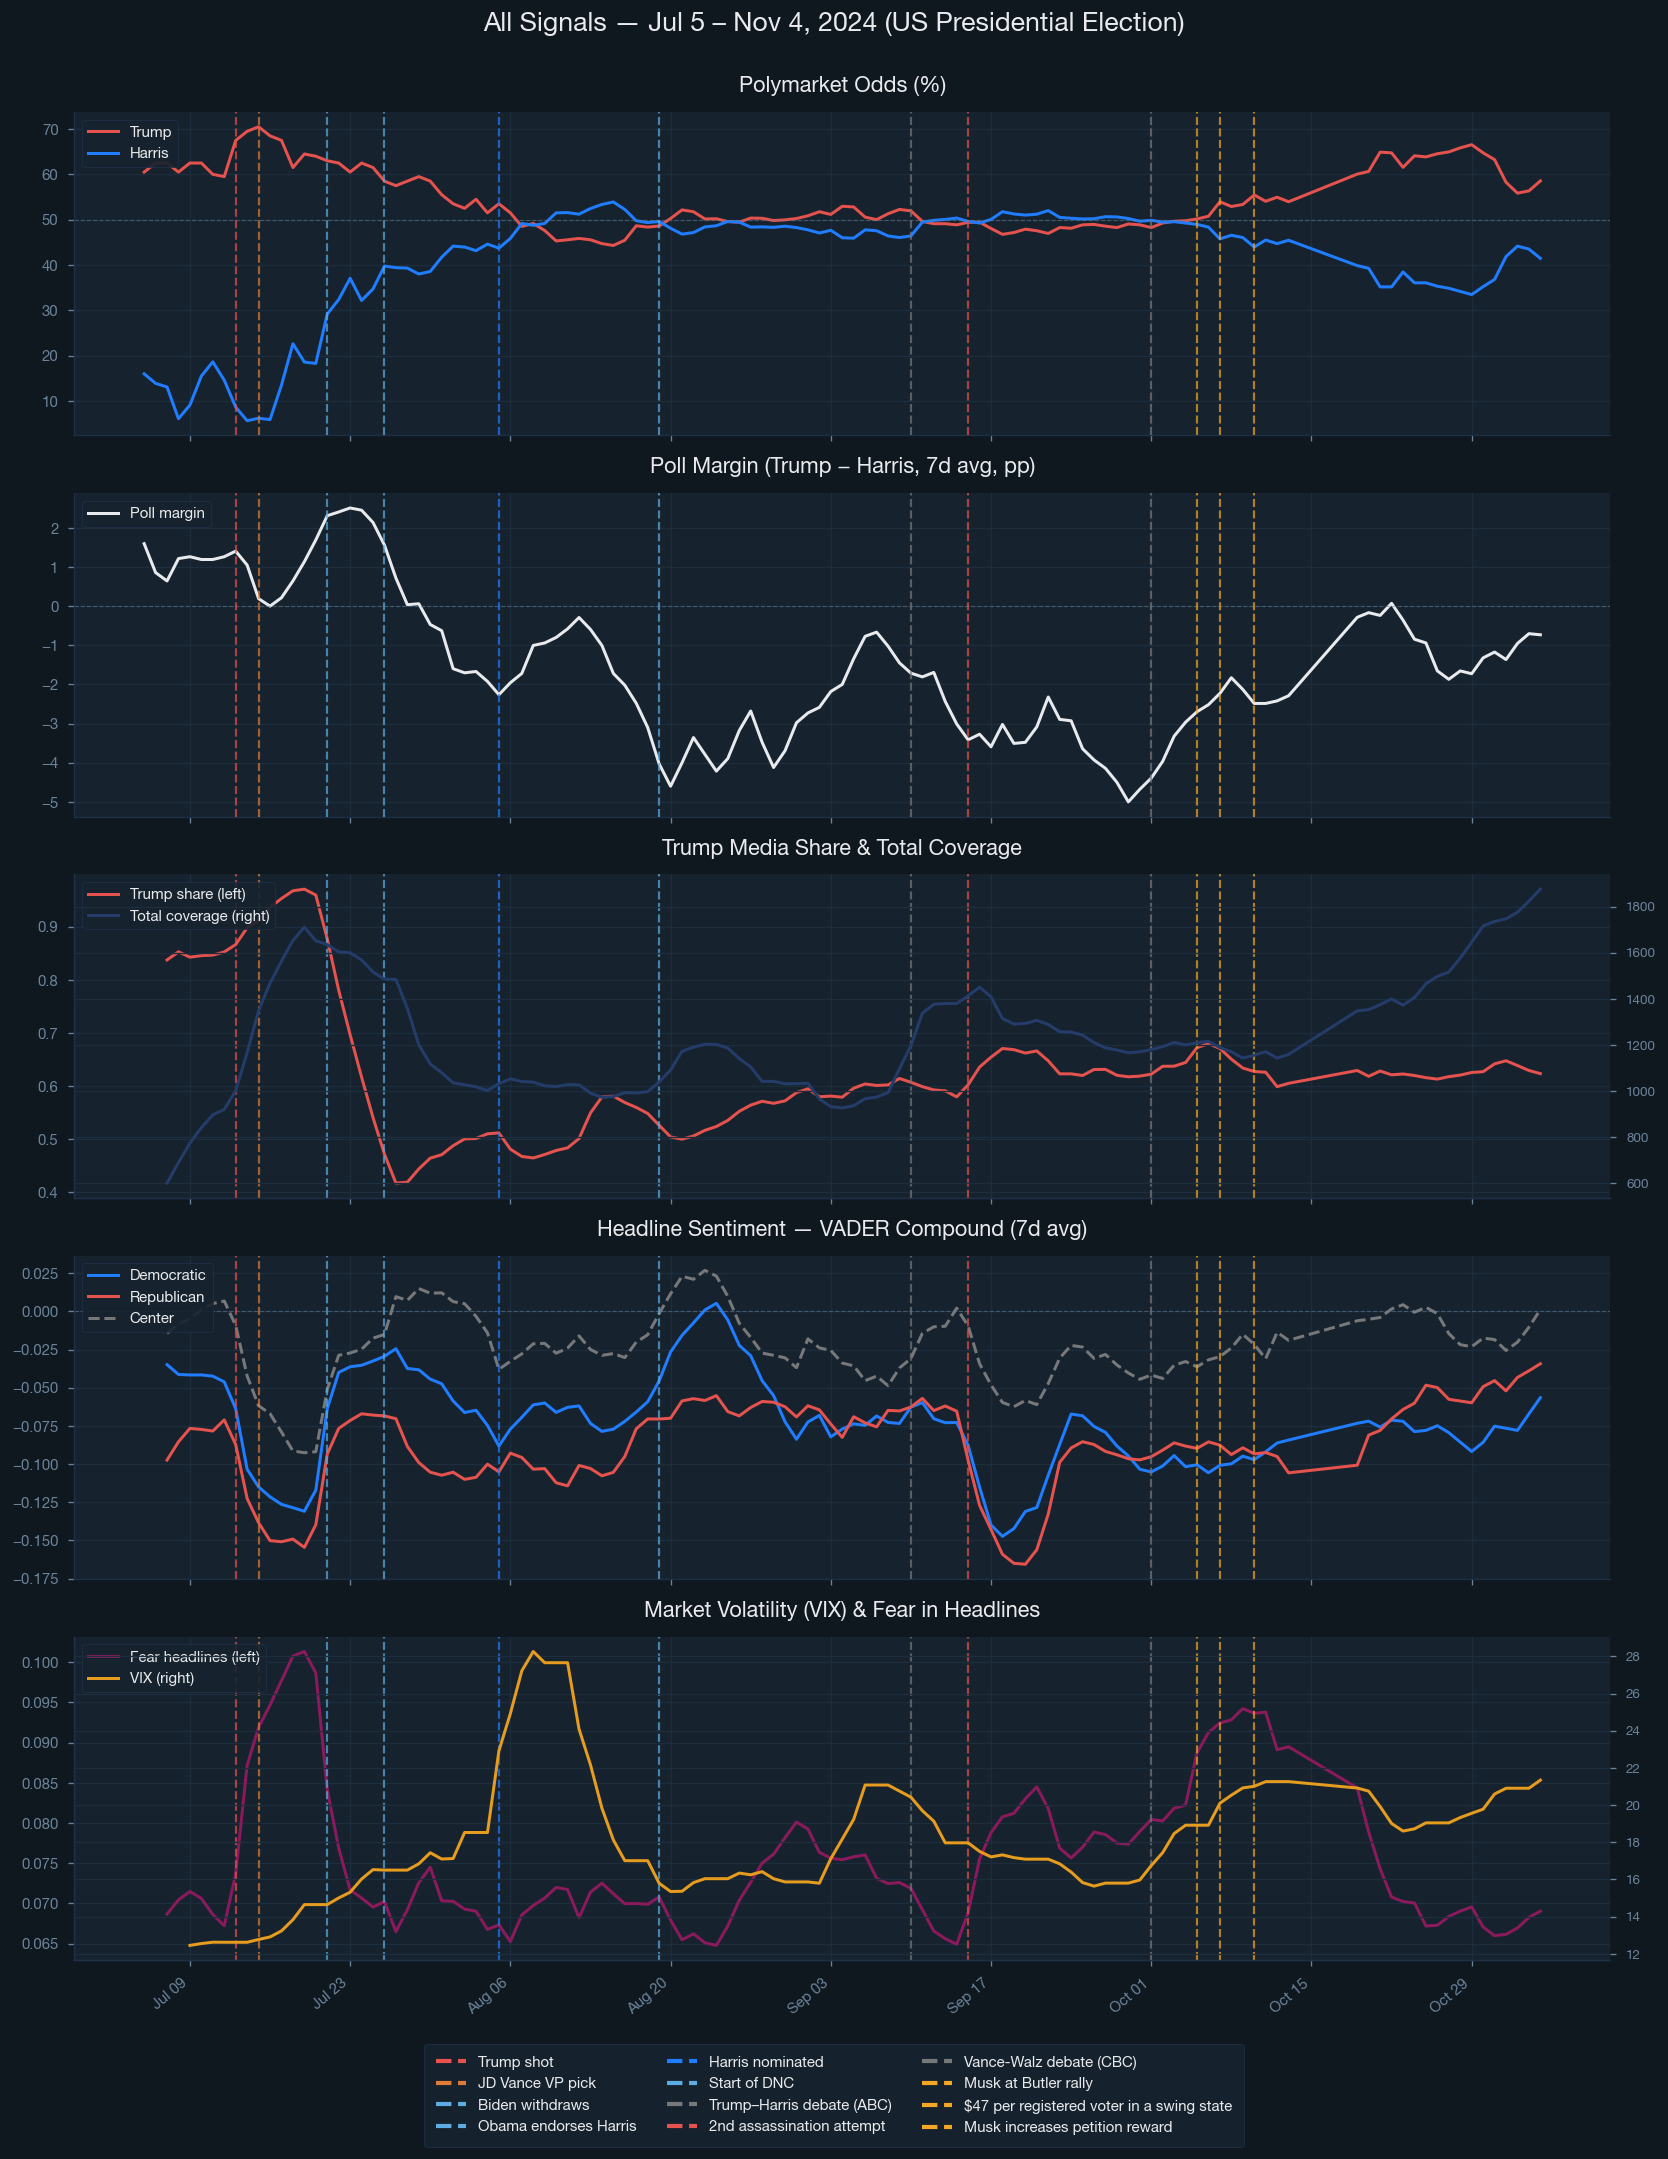

In [39]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

panels = [
    (0, 'Polymarket Odds (%)',
     [('trump_odds',  C_TRUMP,  'Trump',  '-',  False),
      ('harris_odds', C_HARRIS, 'Harris', '-',  False)]),

    (1, 'Poll Margin (Trump − Harris, 7d avg, pp)',
     [('poll_margin_7d', TEXT_PRIMARY, 'Poll margin', '-', False)]),

    (2, 'Trump Media Share & Total Coverage',
     [('trump_share_7d',    C_TRUMP, 'Trump share (left)',      '-',  False),
      ('total_coverage_7d', ACCENT,  'Total coverage (right)',  '-',  True)]),

    (3, 'Headline Sentiment — VADER Compound (7d avg)',
     [('vader_compound_mean_dem', C_DEM, 'Democratic', '-',  False),
      ('vader_compound_mean_rep', C_REP, 'Republican', '-',  False),
      ('vader_compound_mean_cen', C_CEN, 'Center',     '--', False)]),

    (4, 'Market Volatility (VIX) & Fear in Headlines',
     [('VIX',      C_VIX,  'VIX (right)',          '-',   True),
      ('fear_avg', C_FEAR, 'Fear headlines (left)', '-',  False)]),
]

for ax_idx, title, traces in panels:
    ax  = axes[ax_idx]
    ax2 = ax.twinx() if any(t[4] for t in traces) else None
    if ax2:
        style_twin(ax2)

    for col, color, label, ls, secondary in traces:
        if col not in df.columns:
            continue
        already_rolled = col in {'trump_odds','harris_odds','poll_margin_7d',
                                  'trump_share_7d','total_coverage_7d'}
        series = df[col] if already_rolled else df[col].rolling(7, min_periods=3).mean()
        target = ax2 if secondary and ax2 is not None else ax
        target.plot(df['date'], series, color=color, lw=1.8, ls=ls, label=label)

    ax.set_title(title)
    fmt_xaxis(ax)
    add_events(ax)

    lines, labels = ax.get_legend_handles_labels()
    if ax2:
        l2, lb2 = ax2.get_legend_handles_labels()
        lines += l2; labels += lb2
        ax2.tick_params(axis='y', labelsize=8, colors=TEXT_MUTED)
    ax.legend(lines, labels, loc='upper left')

    if ax_idx in [1, 3]:
        ax.axhline(0, color=TEXT_MUTED, lw=0.7, ls='--', alpha=0.5)
    if ax_idx == 0:
        ax.axhline(50, color=TEXT_MUTED, lw=0.7, ls='--', alpha=0.5)

fig.suptitle('All Signals — Jul 5 – Nov 4, 2024 (US Presidential Election)', y=1.002)
plt.tight_layout()
fig.subplots_adjust(bottom=0.1)
event_legend(fig)
plt.show()


### Key Takeaways Key-Events Timeline (All Signals at a Glance)

- **Electoral shocks produce synchronised spikes across all five signal layers** (coverage, sentiment, odds, polls, markets), confirming that major events — Biden's withdrawal, the first debate, assassination attempts — are cross-source turning points, not isolated phenomena.
- **Polymarket odds are the fastest-moving signal**, often adjusting within one day of a key event, while polls and sentiment take three to seven days to fully incorporate new information — consistent with prediction markets being more informationally efficient.
- **Financial markets respond most strongly to events that carry systemic risk** (e.g., late-October uncertainty) rather than to purely electoral news, suggesting that cross-source alignment is strongest when political and economic narratives overlap.
- **The final two weeks stand out as the most informationally dense period**, with all signals converging toward a clear Trump-favourable trajectory — a pattern only visible when all sources are viewed simultaneously, highlighting the value of cross-source integration